In [81]:
import os
from dotenv import load_dotenv
from typing import Annotated, TypedDict
load_dotenv()

True

In [68]:
from langgraph.graph import StateGraph,  START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages

In [69]:
api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key

In [70]:
# Define state
class State(TypedDict):
    messages: Annotated[list[dict], add_messages]

In [71]:
# Setup LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0.7,
)

In [72]:
# Define the chatbot node
def chatbot(state:State):
  return {"messages":[llm.invoke(state["messages"])]}

In [73]:
# Create the state graph
graph=StateGraph(State)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

graph_compile=graph.compile()

In [75]:
result=graph_compile.invoke({"messages":[{"role":"user","content":"Hello, who are you?"}]})

d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [76]:
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Hello! I am Gemini, a large language model created by Google. \n\nHow can I help you today?', 'extras': {'signature': 'Eq8GCqwGARFNMg8Ft7SMm9RHKQrDu01BI9NA+VhFOsEpD5Zg62KulORWgn9S7YcIZ2oQVUUOiubKAGviBhybUXMuNij1AGS9SMk46d83oX+cGTAnAdr91GE/Qtfvc5VgWpeZQYd1bFjDbbzRZ2wj5IC2v+ZP4bZCQ3+Ty+jCRNQhNZxy+G+cDeJ53EHwsXcTblMHCUIBGCvhZx1CBPoy4smwLMibnc3Ta4M2hjIH/LUkdUIYY7CuEwEhGKXM9Bx+xQ2xLC9SiFoiL3E6+K6s7YrmCx/aMpgW41EaptGAkaLntxYFI7m9ORZR3ggf68fUtU6GeysG5JcqgEkF+BrkoNHaofFW4GZcOzBDuENHt83XEOcjNdmeKDaA8e9bMSrnU+R8sLqVQgZKmAcJ6Of2kdW7H8bh7XC/HST3adHsCjbIWBXZNKQ0NL5yfjEDTncXFOOQP5oB+XXWl8vJ/TpQmJ93Nq5XWL9du0zmHHj8aTWZ1pHhWb3uw3I0Ril7cNhdUdGi3EQq0eF/zkAiK8gakuTHaEl6DIf9dVYHmPxYHQ4n9OB2MlkBhxTSxO5VAZ/oB+sjFV1NdCKeIfjUZeo7C85fFGdmh84CeV1qhJvBYo4SRyLd9NrDHHvVO7q4us9LvrBpiurCDfIjqZ+JzSenViuCxUFv5wjjQvh5zWsg8EefDl0BDQZkiYduQ1/RL3QsvtIqMVdzD7+3EC1iWshWJFqQ/lSlYAVyEeCsTENW8UyVVw1pdOjBaoAcknto9FFjGyXoeZQa7Imff7AYAZKbMWvdF+aWhGaSkn/i42yIJxui3voy9krWZDU3/nyM8aR9jD3PRVeyLSjiG9/YeLNFqk

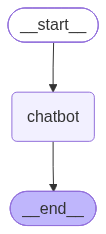

In [77]:
# visualize the graph
from IPython.display import Image
Image(graph_compile.get_graph().draw_mermaid_png())

In [ ]:
# add another node in the above workflow - summary the conversation

def summarize(state:State):
    summary_prompt = {"role": "user", "content": "Please provide a short summary of our conversation above."}
    
    summary = llm.invoke(state["messages"] + [summary_prompt])
    return {"messages": [summary]}

In [84]:
graph = StateGraph(State)
graph.add_node("chatbot", chatbot)
graph.add_node("summarize", summarize)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", "summarize")
graph.add_edge("summarize", END)

graph_compile = graph.compile()

In [85]:
res=graph_compile.invoke({"messages":[{"role":"user","content":"Hello, who are you?"}]})

d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [89]:
print(res["messages"][-1].content)
# This can be example of prompt chaining workflow where the output of one node is used as input to another node. In this case, the chatbot node generates a response based on the user's input, and then the summarize node generates a summary of the conversation.

[{'type': 'text', 'text': 'Here is a short summary of our conversation so far:\n\nYou asked who I am, and I introduced myself as Gemini, an AI created by Google, and offered my assistance.', 'extras': {'signature': 'EpsJCpgJARFNMg9d5diH32OlKJWL/r+TNApzxykSgQDVrvQ7XV7oeYBNuG+hon79tqKG051D4dV2I3la0vRrZ138h7KVapY6CikLfMimFacVCu406SpJBeZl77SJFqdV18/cLIHR+yjY7kTj/mLNPEu8R2s3nncuCm0v531PBg0sBQjv4A7/nDe9ZiWqWSuXT38GdGokJx/VRCNM8Cwfuy979AZ+IgsUbACa5ls/FXgwptsuu77inuCdTl85OSkSRm3fn6OkjhzDO2pRbZUeG5hwldH+FostODP4vTK1rRxcT2CpByloqa4ZQ9bMcjo8G1+J1Q5eZiy9Iyr/o5wF0TlPMlgnC1Cz63eR1anfxc9MtGmItpmmnNwodIzXJSCXDVmcfJHTO21LnoOXdChCOR0CF6+Ry8wIrw+j4yOnetooZNy7qca0Zy/DUgq14g+KPIc5abrYt0itgvehunQ8ZAFFF4j/EHGx4K4lCCOifXpzb4FEw6jqQi78SNmHsZVhXre1q4UlznO2BYhDT7jmfkJE7QdmCMLhsUi+2NiY6HxvghqwC4P5H6XFZsYNHNzCN8KKPHdiW8546HdyJMN9Is7RKgNQ7IsvaTLahWBXmGJRl4xU/4Xi9LoXIyxF4EMwqEUcerOAbGO4QmYCAHhaJoAdSJh6dNBemJIkfDCB4CRbRt+DUE887OozNj6o/KrLytg0dS2FC28dMiLmcKSuE2coEmYmHk+gwl3jziUULSJRiM0+efHSbeBf4+g72dAkRR8lF+2l6Ql0our8

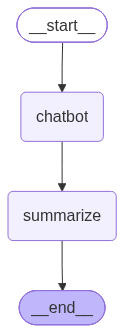

In [87]:
# visualize the graph
from IPython.display import Image
Image(graph_compile.get_graph().draw_mermaid_png())